In [1]:
rm(list = ls())
gc(reset = T)

#Original comentado

library(dplyr)
#library(evola2.1)
library(evola.exp)
library(TSA)
library(forecast)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,653028,34.9,1446568,77.3,653028,34.9
Vcells,1199338,9.2,8388608,64.0,1199338,9.2



Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Adjuntando el paquete: 'TSA'


The following objects are masked from 'package:stats':

    acf, arima


The following object is masked from 'package:utils':

    tar


Registered S3 methods overwritten by 'forecast':
  method       from
  fitted.Arima TSA 
  plot.Arima   TSA 



In [4]:


# Establece directorio
#def_user("jaguilar", servidor = "h165")
evola.exp::def_user(user = "evazquez", servidor = "165")

In [5]:
# Establecer rango de años
year1 <- 2000
year2 <- as.numeric(format(Sys.Date(), "%Y")) - 1 #Obtener anio anterior
years <- c(2001, 2008, 2012, 2018, 2021)

## Datos horarios de O3
o3.h <- evola.exp::redes_con(start = year1, end = year2)

# Datos horarios de O3 temporales
o3.ht <- evola.exp::redes_con(start = year1, end = year2, temporal = T) %>% 
  dplyr::filter(!date %in% o3.h$date) # Esto es solo para comparar si estan las mismas fechas en bases diferentes
# En este caso comparaba las fechas de validados con temporales


In [6]:

# Junta validados con temporales
# Filtra estaciones transporte de 2018 en adelante
# Transporte se quita desde 2017
o3.h <- rbind(o3.h, o3.ht) %>% 
  dplyr::filter(!(as.numeric(format(date, "%Y")) >= 2017 & id_station %in% c("ACO", "AJU", "INN", "MON", "MPA"))) 

# o3.h <- con_rama_con_2("o3", year1, year2)
# o3.ht <- con_rama_con_2("o3", year1, year2, temporal = T) %>% filter(!date %in% o3.h$date)

# o3.h <- rbind(o3.h, o3.ht) %>%
#   filter(!(as.numeric(format(date, "%Y")) >= 2017 & id_station %in% c("ACO", "AJU", "INN", "MON", "MPA")))

## Maximos diarios
o3.d <- o3.h %>%
  dplyr::group_by(date = as.Date(date)) %>%
  dplyr::summarise(valor = max(valor, na.rm = T))


## Conteo de contingencias por mes y año en temporada de ozono - 15 febrero a 15 junio
o3.temp <- o3.d %>%
  dplyr::filter(format(date, "%m") %in% sprintf("%02d", 2:6),
         !format(date, "%m-%d") %in% paste("02", sprintf("%02d", 1:14), sep = "-"),
         !format(date, "%m-%d") %in% paste("06", 16:30, sep = "-")) %>%
  dplyr::group_by(year = format(date, "%Y"), month = factor(format(date, "%B"), c("febrero", "marzo", "abril", "mayo", "junio"))) %>%
  dplyr::summarise(ndias = sum(valor >= 155))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year and month.
ℹ Output is grouped by year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, month))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


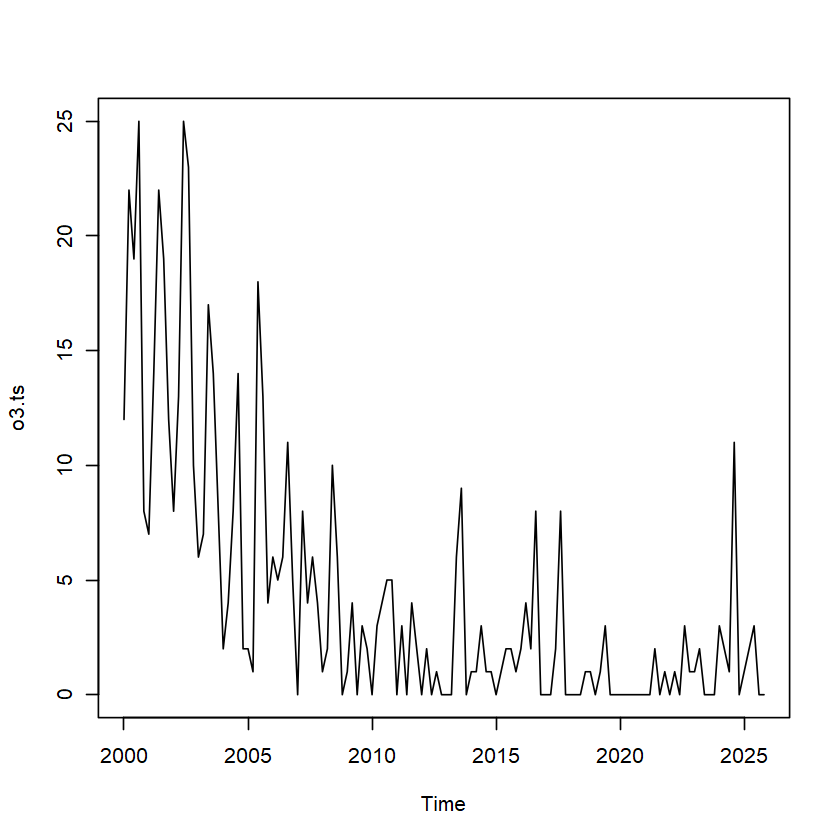

In [9]:
# Serie de tiempo

# Serie para temporada de ozono
o3.ts <- ts(o3.temp$ndias, start = c(year1, 1), end = c(year2, 5), frequency = 5)
plot(o3.ts)


Series: o3.ts 
ARIMA(1,0,1)(2,1,0)[5] 

Coefficients:
         ar1      ma1     sar1     sar2
      0.9895  -0.8704  -0.7193  -0.4189
s.e.  0.0161   0.0597   0.0891   0.0906

sigma^2 = 9.425:  log likelihood = -317.58
AIC=645.16   AICc=645.66   BIC=659.3

Training set error measures:
                     ME     RMSE      MAE MPE MAPE      MASE       ACF1
Training set 0.05426868 2.961826 2.178563 NaN  Inf 0.8617734 -0.0455159


	Ljung-Box test

data:  Residuals from ARIMA(1,0,1)(2,1,0)[5]
Q* = 3.2311, df = 6, p-value = 0.7793

Model df: 4.   Total lags used: 10



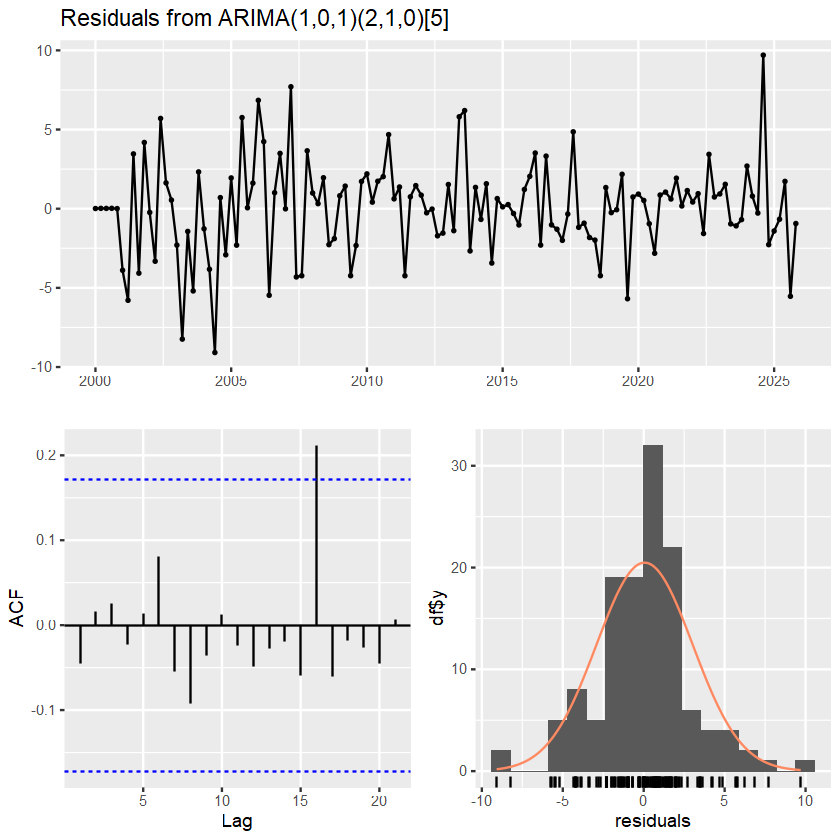

In [10]:
o3.mod.ts <- auto.arima(o3.ts, seasonal = T)

summary(o3.mod.ts)
checkresiduals(o3.mod.ts)

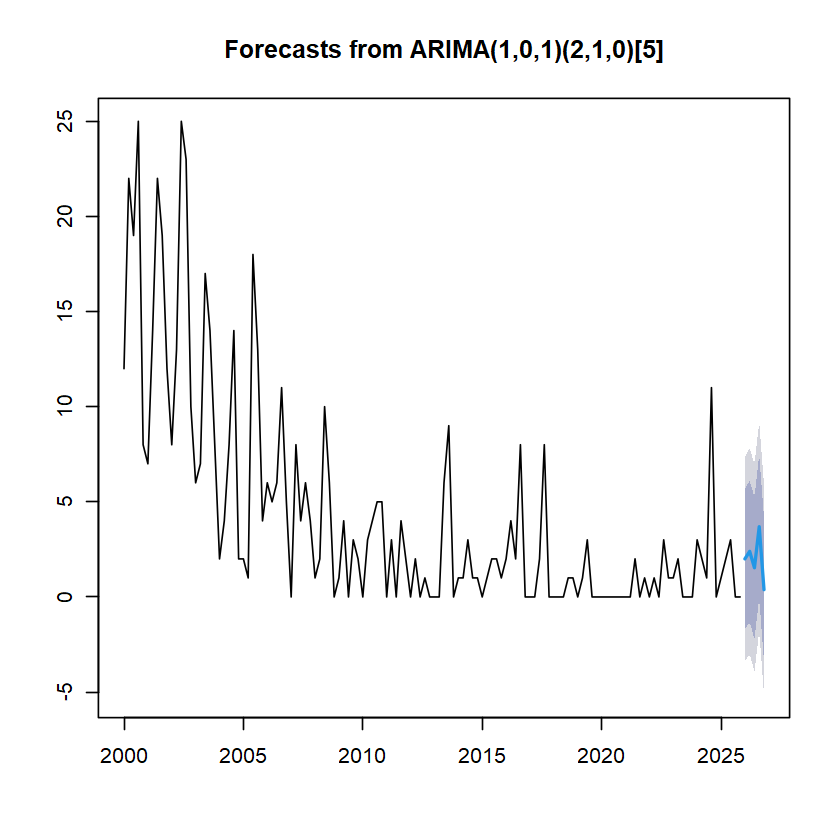

In [16]:
# Se hace el pronostico con el modelo, con intervalo de confianza de 77-92% 
# el argumento "h" es el horizonte de pronostico
# pronostica los proximos 5 periodos (febrero, marzo, abril, mayo, junio)

pronostico <- forecast(o3.mod.ts, h = 5, level = c(77, 92))

## Ajuste del pronostico
if(min(pronostico$mean) < 0){
  aju <- round(min(pronostico$mean))
  pronostico$mean <- round(pronostico$mean) - aju
  pronostico$fitted <- pronostico$fitted - aju
}
plot(pronostico)

## Tabla de pronostico de dias por mes
pron.dias <- data.frame(month = factor(c("febrero","marzo","abril","mayo","junio")),
                        min = pronostico$mean,
                        p_80 = round(pronostico$upper[,1]),
                        p_95 = round(pronostico$upper[,2]))
  



In [17]:
o3.temp <- merge(o3.temp, pron.dias, by = "month")

probs <- o3.temp %>%
  dplyr::filter(year %in% years) %>%
  dplyr::group_by(month) %>%
  dplyr::summarise(prob_80 = sum(ndias <= first(p_80))/n(),
            prob_95 = sum(ndias <= first(p_95))/n())


## Tabla final con el pronostico de dias por mes
tabla.exp <- data.frame(mes = as.character(pron.dias$month),
                        Minimo = as.integer(round(pron.dias$min)),
                        Promedio = as.integer(round(pron.dias$p_80*probs$prob_80)),
                        Maximo = as.integer(round(pron.dias$p_95*probs$prob_95)))

total <- tabla.exp %>% 
  dplyr::summarise(Minimo = sum(Minimo),
                   Promedio = sum(Promedio),
                   Maximo = sum(Maximo)) %>% 
  dplyr::mutate(mes = "Total") %>% 
  dplyr::relocate(mes)

tabla.exp <- rbind(tabla.exp, total)

In [18]:
tabla.exp

mes,Minimo,Promedio,Maximo
<chr>,<int>,<int>,<int>
febrero,2,5,7
marzo,2,5,6
abril,2,3,4
mayo,4,6,7
junio,0,3,5
Total,10,22,29


In [19]:
getwd()

[1] "C:/Users/analisis"